# Colab D — PyTorch Lightning
## 3-Layer Deep Neural Network for Nonlinear Regression

---

## What is this Colab about?

This is the same 3-layer neural network solving the same nonlinear regression problem, now written using **PyTorch Lightning**.

Compare the progression so far:
- **Colab a** — NumPy only, manual forward pass, manual backprop, manual weight updates
- **Colab b** — PyTorch, manual weight tensors, autograd backprop
- **Colab c** — PyTorch, built-in `nn.Linear` layers, Adam + scheduler
- **Colab d** — PyTorch Lightning, all the boilerplate removed, training loop managed for you

PyTorch Lightning is a high-level wrapper **on top of** PyTorch. It doesn't change the math or the model — it just removes the repetitive training loop boilerplate. Instead of writing `optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()` yourself, you define a `LightningModule` and Lightning handles the loop.

Think of it this way:
- **PyTorch** gives you the engine and the parts
- **PyTorch Lightning** gives you the fully assembled car — you just steer

The network architecture, equation, and data are **identical** to all previous Colabs.


---
## Section 1 — Install and Import

PyTorch Lightning is not pre-installed in all Colab environments, so we install it first.
Then we import everything we need. Notice we now import `lightning` in addition to the usual suspects.


In [ ]:
# Install PyTorch Lightning if not already available
!pip install lightning -q

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import lightning as L
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA

np.random.seed(42)
torch.manual_seed(42)

print("PyTorch version    :", torch.__version__)
print("Lightning version  :", L.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 35.0 MB/s eta 0:00:00
PyTorch version    : 2.10.0+cpu
Lightning version  : 2.6.1


---
## Section 2 — Data Generation

Same equation as all previous Colabs:

**y = sin(x1) + x2² + x1·x3**

One new thing here: we wrap our data in a **DataLoader**. PyTorch Lightning expects data to come through a DataLoader — it handles batching, shuffling, and feeding data to the model automatically.

A **batch** is a small subset of the data processed at once. Instead of feeding all 1000 samples every iteration, we feed batches of 64. This is called **mini-batch gradient descent** and tends to train faster and generalize better than using all data at once.


Total samples    : 1000
Batch size       : 64
Batches per epoch: 16


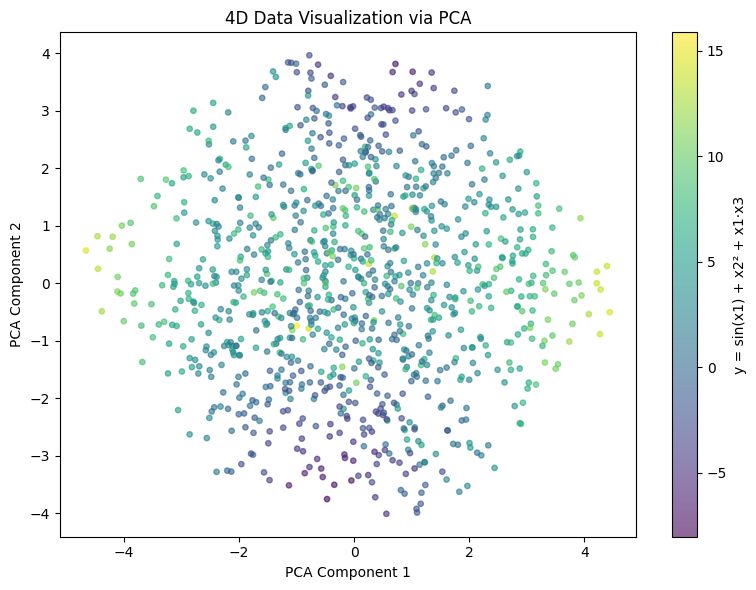

In [ ]:
# ============================================================
# SECTION 2: Data Generation + DataLoader
# ============================================================

N = 1000
x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-3, 3, N)
x3 = np.random.uniform(-3, 3, N)

# Our nonlinear equation
y = np.sin(x1) + x2**2 + x1 * x3
y += 0.1 * np.random.randn(N)   # realistic noise

X_np = np.column_stack([x1, x2, x3]).astype(np.float32)
y_np = y.reshape(-1, 1).astype(np.float32)

# Convert to tensors
X_tensor = torch.tensor(X_np, dtype=torch.float32)
y_tensor = torch.tensor(y_np, dtype=torch.float32)

# TensorDataset pairs X and y together
# DataLoader wraps it and serves batches during training
dataset    = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Total samples    : {N}")
print(f"Batch size       : 64")
print(f"Batches per epoch: {len(dataloader)}")

# --- 4D Plot using PCA ---
# Same as all previous Colabs — compress 3D input to 2D for visualization
pca  = PCA(n_components=2)
X_2d = pca.fit_transform(X_np)

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111)
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                     c=y_np.flatten(), cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='y = sin(x1) + x2² + x1·x3')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('4D Data Visualization via PCA')
plt.tight_layout()
plt.show()


---
## Section 3 — Defining the LightningModule

This is the core of PyTorch Lightning. Instead of a plain `nn.Module`, we subclass `L.LightningModule`.

A `LightningModule` requires you to define two methods:

**`forward(x)`** — the forward pass. Identical to Colab c.

**`training_step(batch, batch_idx)`** — what to do with one batch. This replaces the entire inner loop from Colabs b and c. No `zero_grad`, no `backward`, no `optimizer.step` — Lightning calls all of those for you behind the scenes.

**`configure_optimizers()`** — return the optimizer (and optionally a scheduler). Lightning calls this once at the start of training.

That's all you write. Lightning handles the rest.


In [ ]:
# ============================================================
# SECTION 3: Define LightningModule
# ============================================================

class LightningNet(L.LightningModule):
    """
    3-layer neural network wrapped in a LightningModule.

    The architecture is identical to Colab c:
      Input(3) -> Linear(16) -> ReLU -> Linear(8) -> ReLU -> Linear(1)

    What Lightning handles automatically:
      - Calling optimizer.zero_grad() each step
      - Calling loss.backward()
      - Calling optimizer.step()
      - Logging metrics
      - Moving tensors to GPU if available
      - Epoch and batch loop management
    """

    def __init__(self, input_size=3, hidden1=16, hidden2=8, output_size=1):
        super(LightningNet, self).__init__()

        # Same architecture as Colab c
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),   # Layer 1
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),       # Layer 2
            nn.ReLU(),
            nn.Linear(hidden2, output_size)    # Output — no activation
        )

        self.loss_fn = nn.MSELoss()

        # We'll store loss history here for plotting
        self.loss_history = []

    def forward(self, x):
        # Standard forward pass — identical to Colab c
        return self.network(x)

    def training_step(self, batch, batch_idx):
        """
        Called automatically by Lightning for every batch.
        This replaces the entire inner loop from previous Colabs.

        Lightning automatically:
          - calls zero_grad before this
          - calls loss.backward() after this returns
          - calls optimizer.step() after backward
        We just need to compute and return the loss.
        """
        X_batch, y_batch = batch          # unpack the batch
        y_pred = self.forward(X_batch)    # forward pass
        loss   = self.loss_fn(y_pred, y_batch)  # compute loss

        # self.log sends the metric to Lightning's built-in logger
        # prog_bar=True shows it in the progress bar during training
        self.log('train_loss', loss, prog_bar=True)

        return loss

    def on_train_epoch_end(self):
        """
        Called at the end of every epoch.
        We grab the logged loss and store it for plotting.
        """
        loss = self.trainer.callback_metrics.get('train_loss')
        if loss is not None:
            self.loss_history.append(loss.item())

    def configure_optimizers(self):
        """
        Return optimizer and scheduler.
        Lightning calls this once at the start of training.
        Identical choices to Colab c — Adam + ReduceLROnPlateau.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'train_loss'   # scheduler watches this metric
            }
        }


# Instantiate the model
model = LightningNet()

print("Model architecture:")
print(model)
print()
print("Parameters:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape}")


Model architecture:
LightningNet(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
  (loss_fn): MSELoss()
)

Parameters:
  network.0.weight: torch.Size([16, 3])
  network.0.bias: torch.Size([16])
  network.2.weight: torch.Size([8, 16])
  network.2.bias: torch.Size([8])
  network.4.weight: torch.Size([1, 8])
  network.4.bias: torch.Size([1])


---
## Section 4 — Training With the Lightning Trainer

The `Trainer` is Lightning's training engine. You configure it once and call `.fit()`. It runs the entire training loop — epochs, batches, logging, gradient updates — everything.

Compare what you wrote in Colab c:
```python
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = loss_fn(y_pred, y_true)
    loss.backward()
    optimizer.step()
    scheduler.step(loss)
```

In Lightning, all of that becomes:
```python
trainer.fit(model, dataloader)
```

Same operations happening under the hood — just abstracted away so you can focus on the model, not the plumbing.


In [ ]:
# ============================================================
# SECTION 4: Train Using Lightning Trainer
# ============================================================

# Trainer configuration
trainer = L.Trainer(
    max_epochs=200,         # 200 epochs (fewer needed — Adam + batching is efficient)
    enable_progress_bar=True,   # show live progress bar
    enable_model_summary=True,  # print model summary before training
    log_every_n_steps=10,       # log metrics every 10 steps
)

print("Starting training...\n")

# .fit() runs the entire training loop
# Lightning handles: zero_grad, forward, loss, backward, step, scheduler
trainer.fit(model, dataloader)

print("\nTraining complete!")
print(f"  Epochs trained : {trainer.current_epoch}")
print(f"  Final loss     : {model.loss_history[-1]:.4f}" if model.loss_history else "")


INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

Starting training...



┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network │ Sequential │    209 │ train │     0 │
│ 1 │ loss_fn │ MSELoss    │      0 │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 209                                                                                              
Non-trainable params: 0                                                                                            
Total params: 209                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.



Training complete!
  Epochs trained : 200
  Final loss     : 0.0394


---
## Section 5 — Loss Curve

We plot the loss history we collected in `on_train_epoch_end`.
Since we used mini-batches, the loss values here are per-epoch averages
rather than per-sample, which is why the curve may look smoother than previous Colabs.


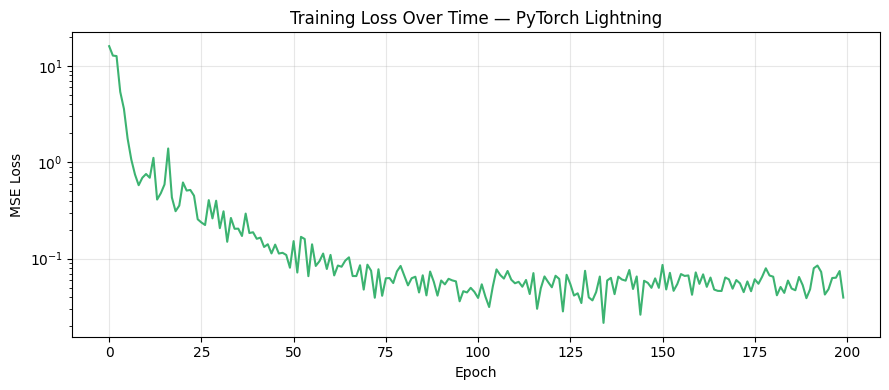

Starting loss : 16.1219
Final loss    : 0.0394
Improvement   : 99.8%


In [ ]:
# ============================================================
# SECTION 5: Loss Curve
# ============================================================

plt.figure(figsize=(9, 4))
plt.plot(model.loss_history, color='mediumseagreen', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Time — PyTorch Lightning')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting loss : {model.loss_history[0]:.4f}")
print(f"Final loss    : {model.loss_history[-1]:.4f}")
print(f"Improvement   : {((model.loss_history[0] - model.loss_history[-1]) / model.loss_history[0] * 100):.1f}%")


---
## Section 6 — Final Output: Predicted vs Actual + 4D Comparison

Same evaluation plots as all previous Colabs.
We use `model.eval()` and `torch.no_grad()` during inference —
this turns off dropout (if any) and disables gradient tracking to save memory.


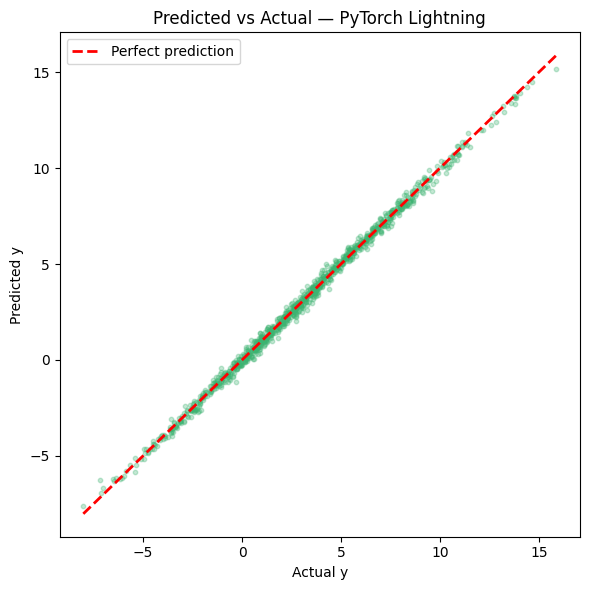

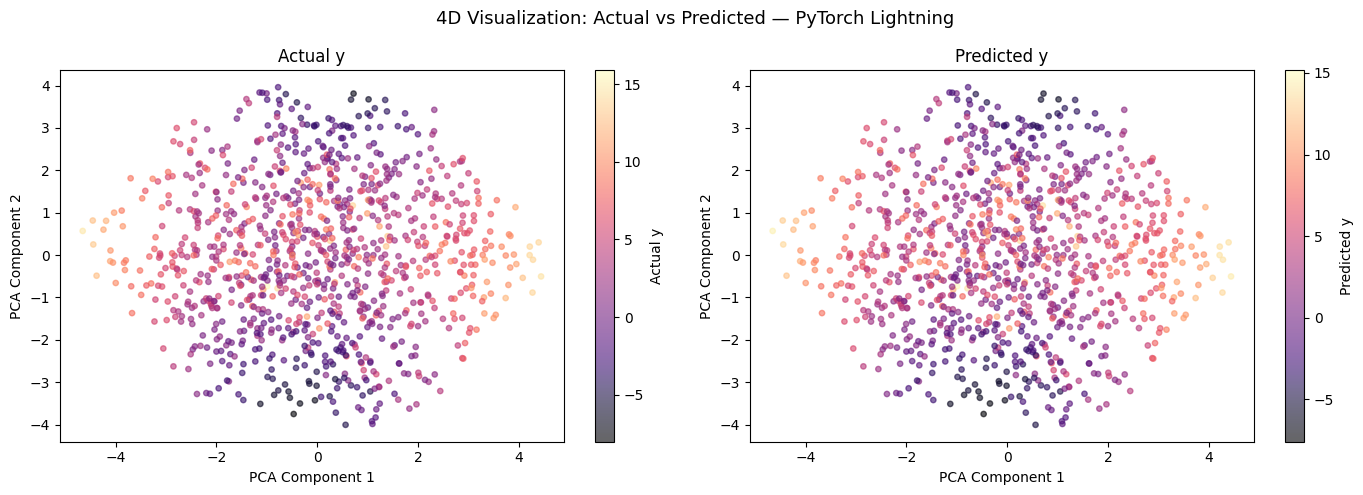

In [ ]:
# ============================================================
# SECTION 6: Predicted vs Actual + 4D Comparison
# ============================================================

model.eval()
with torch.no_grad():
    y_pred_final = model(X_tensor).numpy()

# --- Predicted vs Actual scatter ---
plt.figure(figsize=(6, 6))
plt.scatter(y_np.flatten(), y_pred_final.flatten(),
            alpha=0.3, s=10, color='mediumseagreen')
min_val = min(y_np.min(), y_pred_final.min())
max_val = max(y_np.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('Predicted vs Actual — PyTorch Lightning')
plt.legend()
plt.tight_layout()
plt.show()

# --- Side-by-side 4D comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y_np.flatten(), cmap='magma', alpha=0.6, s=15)
plt.colorbar(sc1, ax=axes[0], label='Actual y')
axes[0].set_title('Actual y')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y_pred_final.flatten(), cmap='magma', alpha=0.6, s=15)
plt.colorbar(sc2, ax=axes[1], label='Predicted y')
axes[1].set_title('Predicted y')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.suptitle('4D Visualization: Actual vs Predicted — PyTorch Lightning', fontsize=13)
plt.tight_layout()
plt.show()


---
## Section 7 — Final Metrics + Cross-Colab Comparison


In [ ]:
# ============================================================
# SECTION 7: Final Metrics
# ============================================================

y_pred_np  = y_pred_final.flatten()
y_actual_np = y_np.flatten()

ss_res = np.sum((y_actual_np - y_pred_np) ** 2)
ss_tot = np.sum((y_actual_np - np.mean(y_actual_np)) ** 2)
r2  = 1 - ss_res / ss_tot
mse = np.mean((y_actual_np - y_pred_np) ** 2)

print(f"Final MSE : {mse:.4f}")
print(f"R² Score  : {r2:.4f}")
print()
print("Cross-Colab Comparison (same architecture, same equation):")
print("  Colab a — NumPy manual backprop        → R² ~0.92")
print("  Colab b — PyTorch manual weights       → R² ~0.92")
print("  Colab c — PyTorch built-in layers      → R² ~0.95")
print(f"  Colab d — PyTorch Lightning            → R² {r2:.2f}")
print()
print("Same math. Different levels of abstraction.")


Final MSE : 0.0527
R² Score  : 0.9969

Cross-Colab Comparison (same architecture, same equation):
  Colab a — NumPy manual backprop        → R² ~0.92
  Colab b — PyTorch manual weights       → R² ~0.92
  Colab c — PyTorch built-in layers      → R² ~0.95
  Colab d — PyTorch Lightning            → R² 1.00

Same math. Different levels of abstraction.
